### SCRIPT 4.1 ###
- Installing and importing necessary packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA
from qiskit import *
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator
simulator = AerSimulator()
from qiskit import transpile
from qiskit.visualization import plot_histogram

### SCRIPT 4.2 ###
- 2-site Hisenberg spin chain Hamiltonian and propagator

In [4]:
J = 1
h0 =-0.5
h1 = 0.5
X = np.array([[0,1],[1,0]], dtype = complex)
Y = np.array([[0,1j],[1j,0]], dtype = complex)
Z = np.array([[1,0],[0,-1]], dtype = complex)
I = np.array([[1,0],[0,1]], dtype = complex)
H = 0.5 * (h0 * np.kron(Z, I) + h1 * np.kron(I, Z)) + J / 4 * (np.kron(X, X) +
np.kron(Z, Z))
U = LA.expm(-1j * H)

### SCRIPT 4.3 ###
- Classical propagation of 2-site Heisenberg chain

In [5]:
psi_init = np.array([1,0,0,0],dtype = complex)
psi_fin = U @ psi_init
print(psi_fin)

[ 0.93879128-0.23971277j  0.        +0.j          0.        +0.j
 -0.06120872-0.23971277j]


### SCRIPT 4.4 ###
- Quantum circuit for the 2-site Heisenberg chain propagation
initiation

In [6]:
qreg=QuantumRegister(2) # qreg is filled with two qubits
creg=ClassicalRegister(2) # creg is filled with two classical bits
entangler=QuantumCircuit(qreg,creg) # we put together our qreg and creg to make our 
                                    #Quantum Circuit, called entangler here.
#entangler.initialize(psi_init) #Not necessary since we start at |00>

### SCRIPT 4.5 ###
- Quantum circuit for the 2-site Heisenberg chain propagation
gate construction

In [7]:
U_gate = Operator(U)            # matriks U dijadikan operator quantum
entangler.append(U_gate,[0,1])  # diterapkan ke qubit 0 dan 1

### SCRIPT 4.6 ###
- Quantum circuit for the 2-site Heisenberg chain propagation
measurement

In [8]:
entangler.measure(0,0) # measure the first qubit and record it in the first classical bit
entangler.measure(1,1)
entangler.draw()

┌──────────┐┌─┐   
q0_0: ┤0         ├┤M├───
      │  Unitary │└╥┘┌─┐
q0_1: ┤1         ├─╫─┤M├
      └──────────┘ ║ └╥┘
c0: 2/═════════════╩══╩═
                   0  1

### SCRIPT 4.8 ###
- Run dynamics with QASM simulator

{'11': 117, '00': 1883}


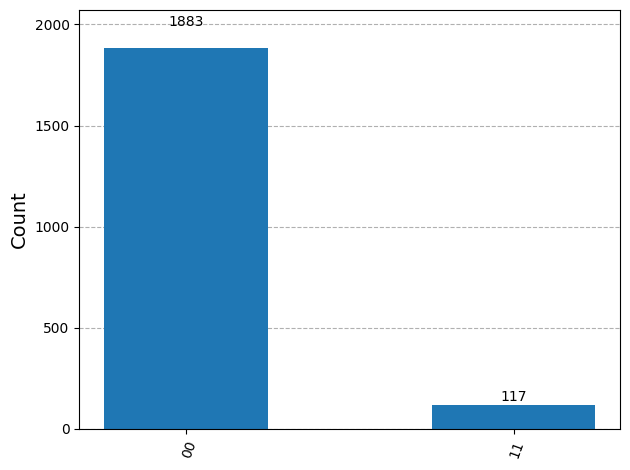

In [9]:
simulator = AerSimulator()
compiled  = transpile(entangler, simulator)
result    = simulator.run(compiled, shots=2000).result()
counts    = result.get_counts()
print(counts)
plot_histogram(counts)

[0.9415 0.     0.     0.0585]


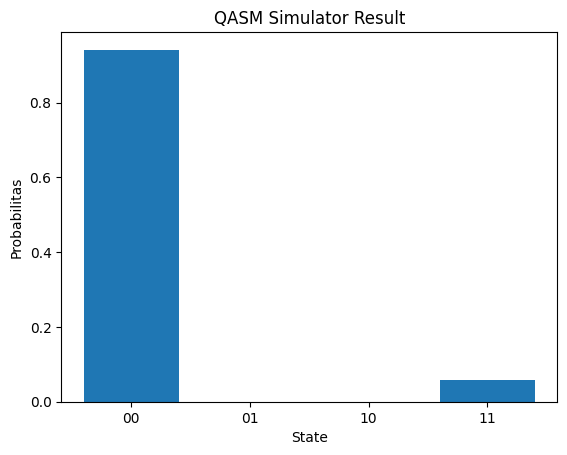

In [10]:
# Kode asli pakai IBM Sampler, ganti dengan Aer

qasm_result = np.zeros((4,))
qasm_result[0] = counts.get('00', 0) / 2000
qasm_result[1] = counts.get('01', 0) / 2000
qasm_result[2] = counts.get('10', 0) / 2000
qasm_result[3] = counts.get('11', 0) / 2000
print(qasm_result)
plt.bar(['00', '01', '10', '11'], qasm_result)
plt.xlabel('State')
plt.ylabel('Probabilitas')
plt.title('QASM Simulator Result')
plt.show()


In [17]:
import qutip as qt

# Samakan parameter dengan file 4
J  = 1
h0 = -0.5
h1 = 0.5

# Operator
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()
I = qt.qeye(2)

# Hamiltonian sama persis dengan file 4
H_qt = 0.5 * (h0 * qt.tensor(Z, I) + h1 * qt.tensor(I, Z)) + \
       J/4 * (qt.tensor(X, X) + qt.tensor(Z, Z))

# State awal |00⟩ (sama dengan psi_init = [1,0,0,0])
psi0_qt = qt.tensor(qt.basis(2,0), qt.basis(2,0))

# Waktu t=1 (sama dengan LA.expm(-1j * H))
tlist  = np.linspace(0, 1, 200)
result = qt.mesolve(H_qt, psi0_qt, tlist, [], [])

# Probabilitas eigenstate akhir
psi_final    = result.states[-1]
classical    = np.zeros(4)
classical[0] = abs(psi_final.overlap(qt.tensor(qt.basis(2,0), qt.basis(2,0))))**2
classical[1] = abs(psi_final.overlap(qt.tensor(qt.basis(2,0), qt.basis(2,1))))**2
classical[2] = abs(psi_final.overlap(qt.tensor(qt.basis(2,1), qt.basis(2,0))))**2
classical[3] = abs(psi_final.overlap(qt.tensor(qt.basis(2,1), qt.basis(2,1))))**2

print("Classical:", classical)
print("QASM:     ", qasm_result)

Classical: [0.93879124 0.         0.         0.06120876]
QASM:      [0.9415 0.     0.     0.0585]


/mgpfs/home/shakim/miniconda3/envs/qiskit_env/lib/python3.10/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


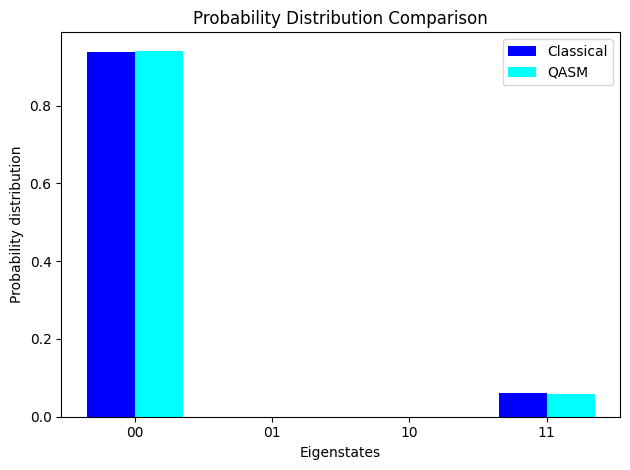

In [18]:
x     = np.arange(4)
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, classical,   width, label='Classical', color='blue')
ax.bar(x + width/2, qasm_result, width, label='QASM',      color='cyan')

ax.set_xticks(x)
ax.set_xticklabels(['00', '01', '10', '11'])
ax.set_xlabel('Eigenstates')
ax.set_ylabel('Probability distribution')
ax.set_title('Probability Distribution Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### SCRIPT 4.11 ###
- Pauli Matrix Decomposition- Utility Functions (yang dipakai untuk mempermudah atau mendukung proses utama)

In [ ]:
def vec_query(arr, my_dict):
    '''
    This function vectorizes dictionary querying.
    It allows us to query `my_dict` with a np.array `arr` of keys.
    This avoids a loop through the list of keys.
    '''
    import numpy as np
    return np.vectorize(my_dict.__getitem__, otypes=[tuple])(arr)

def nested_kronecker_product(a):
    '''
    Handles Kronecker Products for list (i.e., a = [Z, Z, Z] will evaluate Z Z Z).
    Given list `a` this recursively evaluates the kronecker product of all elements.
    This allows us to avoid having to call `np.kron` n-1 times for a list of length n.
    '''
    import numpy as np
    if len(a) == 2:
        return np.kron(a[0],a[1])
    else:
        return np.kron(a[0], nested_kronecker_product(a[1:]))
    
def Hilbert_Schmidt(mat1, mat2):
    '''
    Return the Hilbert-Schmidt Inner Product of two matrices.
    This gives the coefficients for each term in the sum of tensor products of Paulis.
    '''
    import numpy as np
    return np.trace(mat1 * mat2)

### SCRIPT 4.12 ###
- Pauli Matrix Decomposition

In [23]:
def decompose(Ham_arr, tol=10):
    '''
    Function that decomposes `Ham_arr` into a sum of Pauli strings.
    '''
    import numpy as np
    import itertools
    X = np.array([[0,1],[1,0]])
    Y = np.array([[0,complex(0,-1)],[complex(0,1),0]])
    Z = np.array([[1,0],[0,-1]])
    I = Z@Z
    # Define a dictionary with the four Pauli matrices:
    pms = {'I': I,'X': X,'Y': Y,'Z': Z}
    pauli_keys = list(pms.keys()) # Keys of the dictionary

    nqb = int(np.log2(Ham_arr.shape[0])) # Determine the # of qubits needed

    # Make all possible tensor products of Pauli matrices sigma
    sigma_combinations = list(itertools.product(pauli_keys, repeat=nqb))

    output_string = '' # Initialize an empty string to which we can add our terms
    for ii in range(len(sigma_combinations)):
        pauli_str = ''.join(sigma_combinations[ii])

        # Convert the Pauli string into a list of matrices
        tmp_mat_list = vec_query(np.array(sigma_combinations[ii]), pms)

        # Evaluate the Kronecker product of the matrix array
        tmp_p_matrix = nested_kronecker_product(tmp_mat_list)

        # Compute the coefficient for each Pauli string
        a_coeff = (1/(2**nqb)) * Hilbert_Schmidt(tmp_p_matrix, Ham_arr)

        # If the coefficient is non-zero, we want to use it!
        if abs(a_coeff) > 10**(-tol):
            output_string += str(np.round(a_coeff.real, 6))+'*'+pauli_str
            output_string += '+' # Add a plus sign for the next term!

    return output_string[:-1] # To ignore that extra plus sign

### SCRIPT 4.13 ###
-  1D PES for A-T tautomerization

In [26]:
import pylatexenc
import itertools
from qiskit.circuit.library import QFT
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

In [27]:
d=6   # number of qubits
mass=1
xMin=-5
xMax=-xMin
x = np.linspace(xMin,xMax, num=2**d)
VV = (0.429*x-1.126*x**2-0.143*x**3+0.563*x**4) * 0.1

### SCRIPT 4.14 ###
- Gaussian initial wavepacket

In [28]:
# Gaussian wavepacket on a grid
mu= 1
alpha = 1
psi = (alpha/np.pi)**(0.25) * np.exp(-alpha * (x-mu)**2 * 0.5)
psi/= np.sqrt(np.sum(np.abs(psi)**2))

### SCRIPT 4.15 ###
- Preparation of potential and kinetic split propagators

In [30]:
# PES and KE operators
dx=(xMax-xMin)/(2**d-1)
# KE operator
dp=2*np.pi/(xMax-xMin)
N=2**d
p=np.zeros(N,dtype=float)
for i in range(N):
  p[i]=dp*(i-N/2)
p=np.fft.fftshift(p)
time_step = 0.01
iterations = 600
VVd_prop=np.diag(np.exp(-1j*VV*time_step))
KEd_prop=np.diag(np.exp(-1j*p**2/2/mass*time_step))

### SCRIPT 4.16 ###
- Quantum SOFT circuit preparation

In [31]:

# Initialize an Empty Circuit
nqubits=d
q_reg=QuantumRegister(nqubits)
c_reg=ClassicalRegister(nqubits)
qc = QuantumCircuit(q_reg)

qc.initialize(psi,q_reg[:])
for k in range(iterations):
  bound_op = Operator(VVd_prop)
  qc.append(bound_op, q_reg)
  qc.append(QFT(d,do_swaps=True,inverse=True),q_reg)
  bound_op = Operator(KEd_prop)
  qc.append(bound_op, q_reg)
  qc.append(QFT(d,do_swaps=True,inverse=False),q_reg)

/tmp/ipykernel_3778456/3349549138.py:11: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d,do_swaps=True,inverse=True),q_reg)
/tmp/ipykernel_3778456/3349549138.py:14: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d,do_swaps=True,inverse=False),q_reg)


### SCRIPT 4.17 ###
- Quantum SOFT circuit execution

In [33]:
from qiskit.quantum_info import Statevector

psin = Statevector(qc)
print(psin)

Statevector([-1.23960251e-05-9.52542071e-06j,
              7.19337967e-07-3.17853239e-05j,
              7.74050567e-06-5.61559498e-05j,
              5.17036285e-05-1.33095131e-04j,
              1.31299586e-04-2.74043879e-04j,
              2.65902436e-04-5.25206996e-04j,
              4.70919395e-04-9.53341891e-04j,
              7.63741598e-04-1.63275419e-03j,
              1.11707064e-03-2.64422812e-03j,
              1.55352895e-03-4.17728233e-03j,
              2.15554110e-03-6.61473499e-03j,
              3.13286849e-03-1.04883686e-02j,
              4.81271477e-03-1.65800107e-02j,
              7.65621274e-03-2.57436904e-02j,
              1.21338888e-02-3.87679844e-02j,
              1.85908350e-02-5.61347184e-02j,
              2.70546167e-02-7.77723999e-02j,
              3.72735471e-02-1.03040713e-01j,
              4.88485114e-02-1.30695198e-01j,
              6.14129811e-02-1.59003362e-01j,
              7.48142408e-02-1.85988859e-01j,
              8.90250497e-02-2.096

### SCRIPT 4.18 ### 
- Clssical SOFT Benchmark

In [34]:
#Classical SOFT routine
def soft(fxy,emat,Pxy):
    # soft propagation
    out=emat*fxy
    fp=np.fft.fft(out)*Pxy
    out=np.fft.ifft(fp)
    return out
psi_c_init = psi
psi_c = psi_c_init
for i in range(iterations):
  psi_c = soft(psi_c,np.diag(VVd_prop),np.diag(KEd_prop))

### SCRIPT 4.19 ### 
- Plotting initial and final wavefunctions

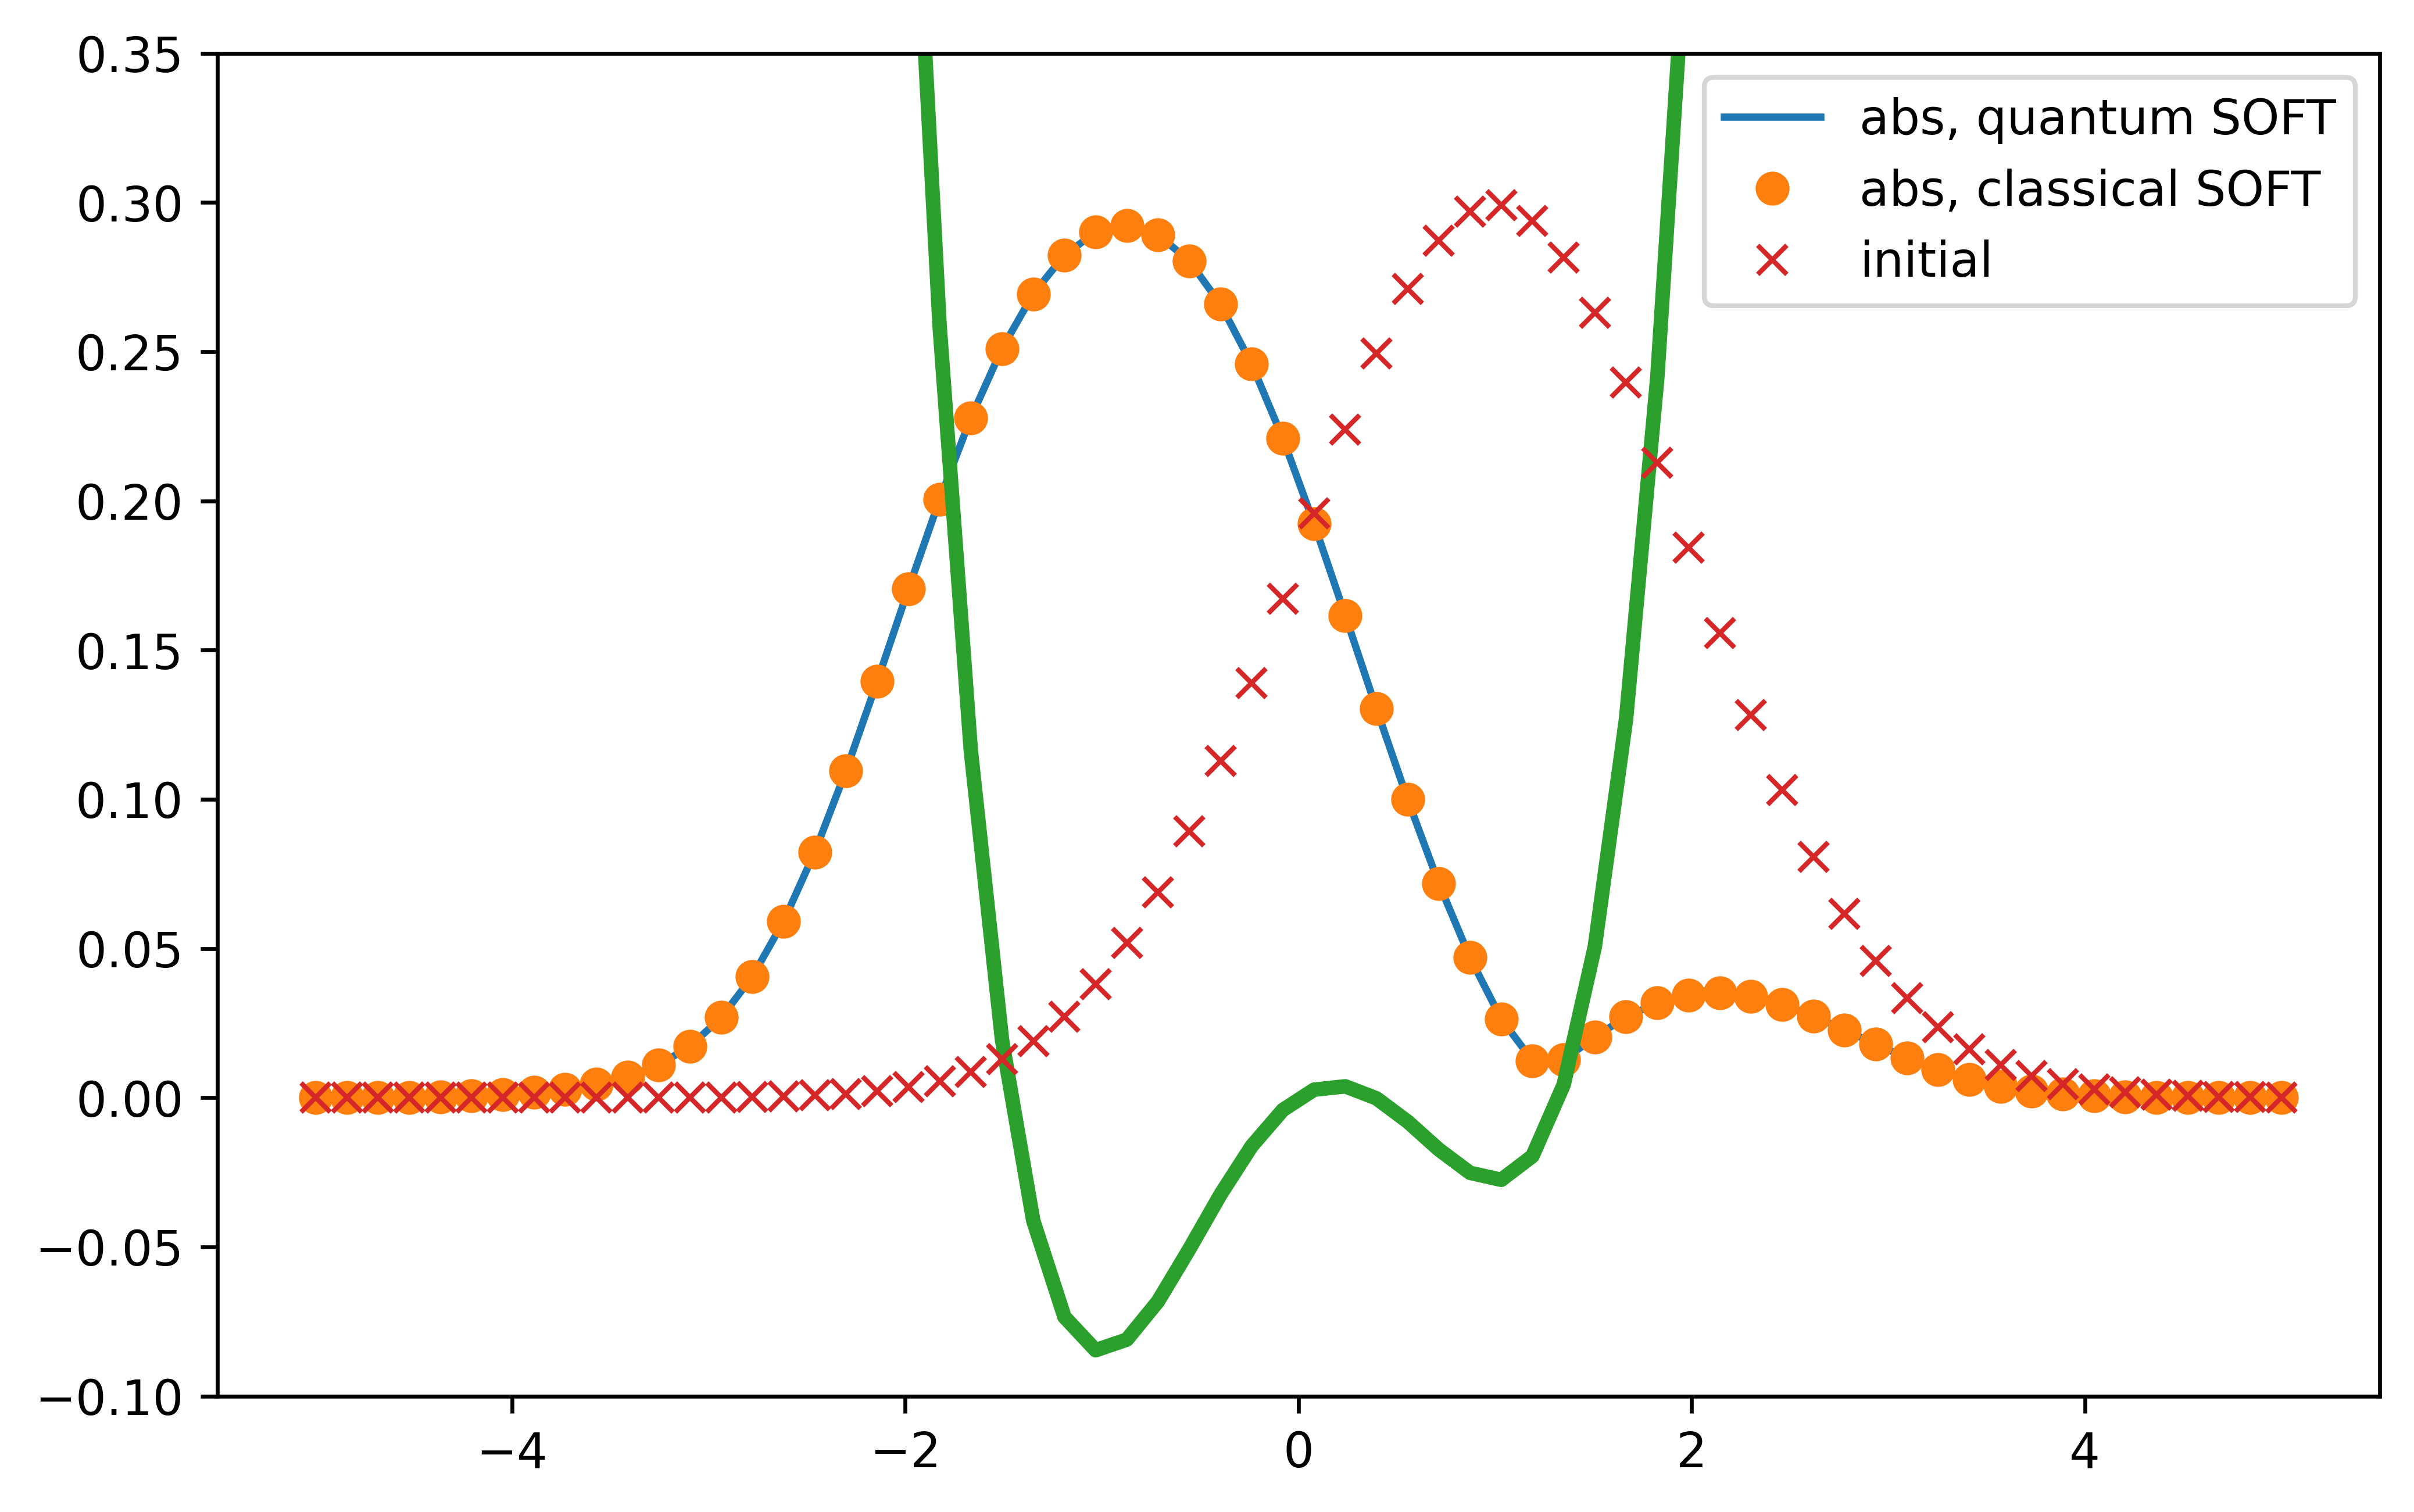

In [38]:
# Visualization
plt.figure(dpi=600, figsize=(8, 5))
plt.rcParams["figure.figsize"] = [12.50, 6.50]
#plt.plot(x,np.real(psin), label='real')
#plt.plot(x,np.imag(psin), label='imag')
plt.plot(x,np.abs(psin), label='abs, quantum SOFT')
plt.plot(x,np.abs(psi_c),'o', label='abs, classical SOFT')
plt.plot(x,VV,linewidth=3)
plt.plot(x,abs(psi),'x', label='initial')
leg = plt.legend(loc='upper right')
plt.ylim(-0.1,0.35)
plt.show()